In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('Mall_Customers.csv')

In [12]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [6]:
df.shape

(200, 5)

In [7]:
df = df.drop(['CustomerID'], axis=1)

In [11]:
df['Gender'] = df['Gender'].apply(lambda x: 1 if x == 'Male' else 0)

In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df)


In [17]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pca = PCA(n_components= 2)
X_pca = pca.fit_transform(df)

<ipython-input-18-447ddb84504a>:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_pca[:, 0], X_pca[:, 1], cmap='viridis')


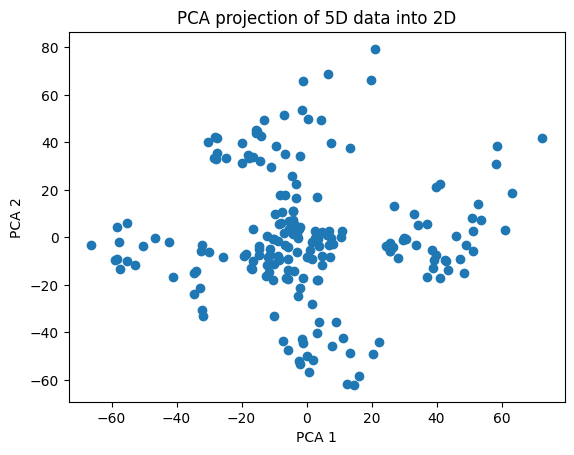

In [18]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], cmap='viridis')
plt.title('PCA projection of 5D data into 2D')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

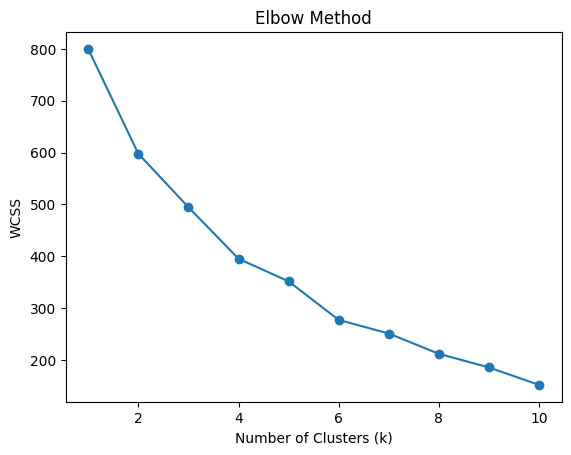

In [25]:
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()

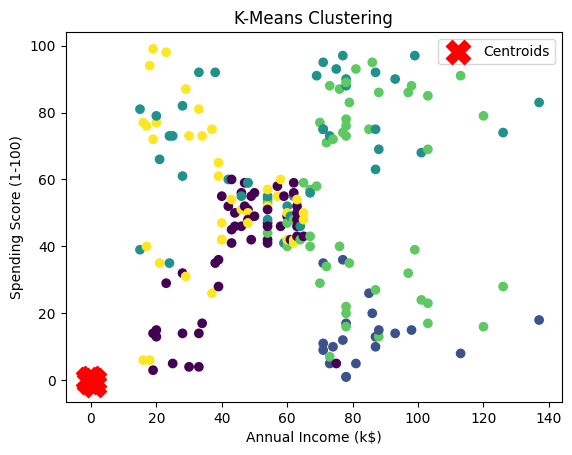

In [26]:
# Perform K-Means with optimal k
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(data_scaled)

# Add cluster labels to the dataset
df['Cluster'] = clusters

# Visualize the clusters
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster'], cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 2], kmeans.cluster_centers_[:, 3], s=300, c='red', marker='X', label='Centroids')
plt.title('K-Means Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [29]:
from sklearn.metrics import silhouette_score

# Calculate Silhouette Score
silhouette_avg = silhouette_score(data_scaled, clusters)
print(f"Silhouette Score for k=5: {silhouette_avg:.4f}")

Silhouette Score for k=5: 0.2719
